# Business Entity Resolution — Feature Engineering & Matcher Report
**Amazon ML Challenge 2026 · Track: Business Entity Resolution**

Match each Source-1 business record to all Source-2/3 records describing the same real
business. Scored by **macro-averaged F₀.₅** — precision weighted 2×, computed per S1
entity then averaged over *all* S1 entities, singletons included.

$$F_{0.5} = \frac{1.25 \cdot P \cdot R}{0.25 \cdot P + R}$$

This report covers the **feature engineering** and **matching model** stages. Candidate
generation (blocking) is upstream and sets a hard recall ceiling that the matcher cannot
exceed.

**Training data for this report:** 6,000 India S1 entities sampled *uniformly* (so
singletons are represented), retrieved against the **full 4,133,346-record pool** with
no cap. 899,995 candidate pairs, 19,601 positives.

In [1]:
import json, os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb
from scipy import stats
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, average_precision_score,
                             confusion_matrix, classification_report, precision_recall_fscore_support)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi':110, 'figure.figsize':(11,4.5), 'axes.titleweight':'bold',
                     'axes.titlesize':11, 'font.size':9})
POS, NEG = '#d62728', '#1f77b4'

# The notebook lives in report/, so anchor every relative path at the repo root.
ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'report' else os.getcwd()
os.chdir(ROOT)
D, M = 'matcher/data', 'matcher/models'
TAG = 'india_fullpool'
X    = np.load(f'{D}/{TAG}_X.npy')
y    = np.load(f'{D}/{TAG}_y.npy').astype(int)
meta = np.load(f'{D}/{TAG}_meta.npz')
cols = json.load(open(f'{D}/{TAG}_cols.json'))['cols']
val  = np.load(f'{M}/{TAG}_val_mask.npy')
booster = lgb.Booster(model_file=f'{M}/{TAG}.lgb')
imp = pd.DataFrame(json.load(open(f'{M}/{TAG}_importance.json')))
print(f'X {X.shape}   positives {y.sum():,} ({100*y.mean():.3f}%)   features {len(cols)}')
print(f'train rows {(~val).sum():,}  |  held-out rows {val.sum():,}')

X (899995, 77)   positives 19,601 (2.178%)   features 77
train rows 674,995  |  held-out rows 225,000


## 1 · Dataset profile

What one row is, and how imbalanced the problem is.

metric,value
candidate pairs,"899,995"
distinct S1 entities,"6,000"
distinct candidate records,"617,426"
positive pairs,"19,601"
negative pairs,"880,394"
class ratio (neg:pos),44.9 : 1
candidates per S1,150.0
S2 share of candidates,50.9%


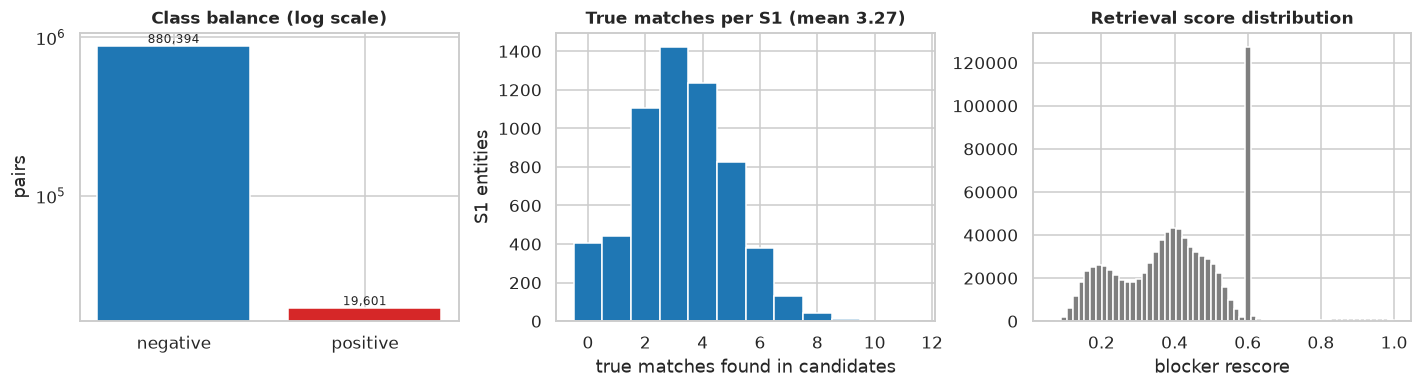

Singletons (zero true matches) in sample: 406 (6.77%)  — population rate is 5.58%


In [2]:
s1 = meta['s1_ids']; cand = meta['cand_ids']; src = meta['src']
df = pd.DataFrame({'s1':s1,'cand':cand,'src':src,'y':y,'val':val,
                   'retrieval_score':meta['rscore']})
n_s1 = df.s1.nunique()
summary = pd.DataFrame({
 'metric':['candidate pairs','distinct S1 entities','distinct candidate records',
           'positive pairs','negative pairs','class ratio (neg:pos)',
           'candidates per S1','S2 share of candidates'],
 'value':[f'{len(df):,}', f'{n_s1:,}', f'{df.cand.nunique():,}', f'{int(y.sum()):,}',
          f'{int((y==0).sum()):,}', f'{(y==0).sum()/y.sum():.1f} : 1',
          f'{len(df)/n_s1:.1f}', f'{100*(src=="S2").mean():.1f}%']})
display(summary.style.hide(axis='index'))

fig, ax = plt.subplots(1,3, figsize=(13,3.6))
ax[0].bar(['negative','positive'],[int((y==0).sum()),int(y.sum())], color=[NEG,POS])
ax[0].set_yscale('log'); ax[0].set_title('Class balance (log scale)'); ax[0].set_ylabel('pairs')
for i,v in enumerate([int((y==0).sum()),int(y.sum())]):
    ax[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

tsz = df[df.y==1].groupby('s1').size().reindex(df.s1.unique(), fill_value=0)
ax[1].hist(tsz.values, bins=np.arange(-0.5,12.5,1), color=NEG, edgecolor='w')
ax[1].set_title(f'True matches per S1 (mean {tsz.mean():.2f})')
ax[1].set_xlabel('true matches found in candidates'); ax[1].set_ylabel('S1 entities')

ax[2].hist(df.retrieval_score, bins=60, color='#7f7f7f')
ax[2].set_title('Retrieval score distribution'); ax[2].set_xlabel('blocker rescore')
plt.tight_layout(); plt.show()
print(f'Singletons (zero true matches) in sample: {(tsz==0).sum():,} '
      f'({100*(tsz==0).mean():.2f}%)  — population rate is 5.58%')

### Why the class ratio matters

At **45 negatives per positive**, accuracy is a meaningless metric — predicting "no match"
everywhere scores 97.8%. Every model metric below is therefore precision/recall based, and
the PR curve is used in preference to ROC.

## 2 · Feature engineering

77 features in four families. None can see a label — the extractor is structurally barred from importing ground truth.

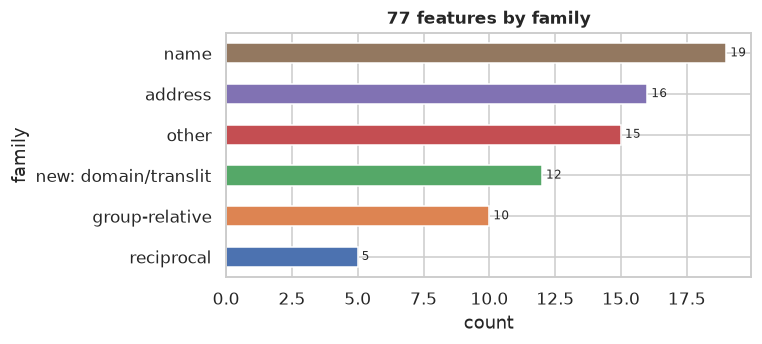

In [3]:
fam = []
for c in cols:
    if c.startswith(('rank_','is_top1','score_','z_score','group_size','frac_above')): f='group-relative'
    elif c.startswith(('rank_reverse','is_mutual','n_competitors','cand_')): f='reciprocal'
    elif c.startswith(('translit','eff_','is_domain')): f='new: domain/translit'
    elif c.startswith('addr'): f='address'
    elif c.startswith('name'): f='name'
    else: f='other'
    fam.append(f)
fdf = pd.DataFrame({'feature':cols,'family':fam})
cnt = fdf.family.value_counts()
fig, ax = plt.subplots(figsize=(7,3.2))
cnt.sort_values().plot.barh(ax=ax, color=sns.color_palette('deep'))
ax.set_title(f'{len(cols)} features by family'); ax.set_xlabel('count')
for i,v in enumerate(cnt.sort_values().values): ax.text(v, i, f' {v}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

### 2.1 Missingness and skewness

Undefined similarity is encoded as **NaN, never 0.0** — a zero would assert *"these disagree"*, which is a false statement about a pair where one side simply has no address. LightGBM handles NaN natively.

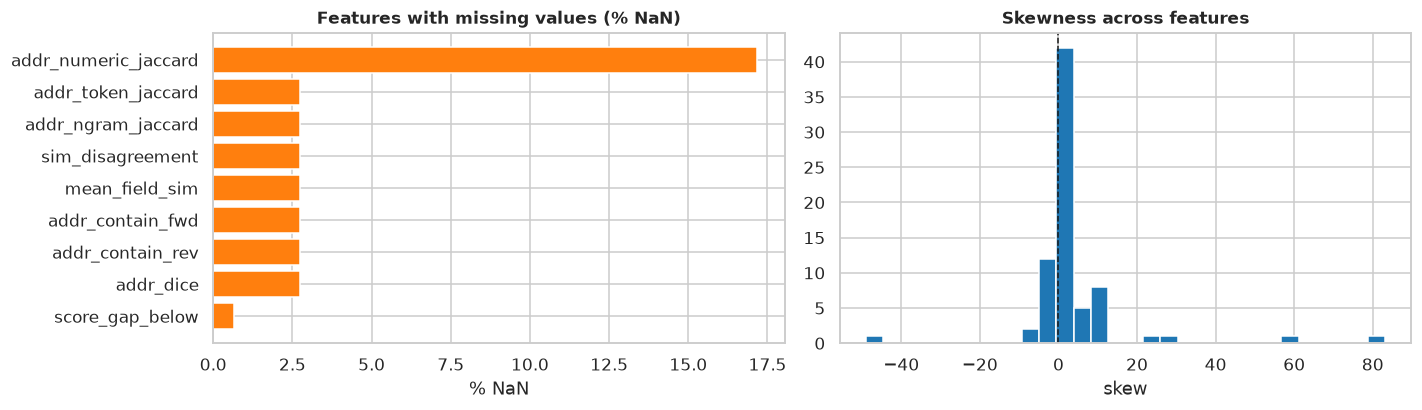

3 constant features: ['addr_missing_both', 'name_missing_either', 'is_domain_l']
Highly skewed (|skew|>3): 23 features — expected: most similarity features are near-zero for the 45:1 negative majority.


feature,pct_nan,mean,std,skewness,constant
name_digits_conflict,0.0,0.000,0.012,83.19,False
name_has_digits_both,0.0,0.000,0.017,58.92,False
group_size,0.0,149.999,0.038,-49.03,False
both_high,0.0,0.001,0.034,29.20,False
addr_exact,0.0,0.002,0.046,21.69,False
is_mutual_best,0.0,0.007,0.081,12.14,False
is_top1,0.0,0.007,0.081,12.12,False
name_low_addr_high,0.0,0.007,0.086,11.42,False


In [4]:
prof = []
for k,c in enumerate(cols):
    v = X[:,k]; f = v[np.isfinite(v)]
    prof.append({'feature':c,'pct_nan':100*(1-f.size/v.size),
                 'mean':f.mean() if f.size else np.nan,
                 'std':f.std() if f.size else np.nan,
                 'skewness':stats.skew(f) if f.size>2 else np.nan,
                 'constant': f.size==0 or np.ptp(f)==0})
prof = pd.DataFrame(prof)
fig, ax = plt.subplots(1,2, figsize=(13,3.8))
nz = prof[prof.pct_nan>0].sort_values('pct_nan', ascending=False).head(12)
ax[0].barh(nz.feature[::-1], nz.pct_nan[::-1], color='#ff7f0e')
ax[0].set_title('Features with missing values (% NaN)'); ax[0].set_xlabel('% NaN')
ax[1].hist(prof['skewness'].dropna(), bins=30, color=NEG, edgecolor='w')
ax[1].axvline(0, color='k', lw=1, ls='--')
ax[1].set_title('Skewness across features'); ax[1].set_xlabel('skew')
plt.tight_layout(); plt.show()
print(f"{prof.constant.sum()} constant features: {prof[prof.constant].feature.tolist()}")
print(f"Highly skewed (|skew|>3): {int((prof['skewness'].abs()>3).sum())} features — "
      f"expected: most similarity features are near-zero for the 45:1 negative majority.")
display(prof.reindex(prof['skewness'].abs().sort_values(ascending=False).index).head(8)
        .style.format({'pct_nan':'{:.1f}','mean':'{:.3f}','std':'{:.3f}','skewness':'{:.2f}'}).hide(axis='index'))

### 2.2 Do the features separate the classes?

Distribution of the top discriminating features, split by label. Clean separation here is what the model exploits.

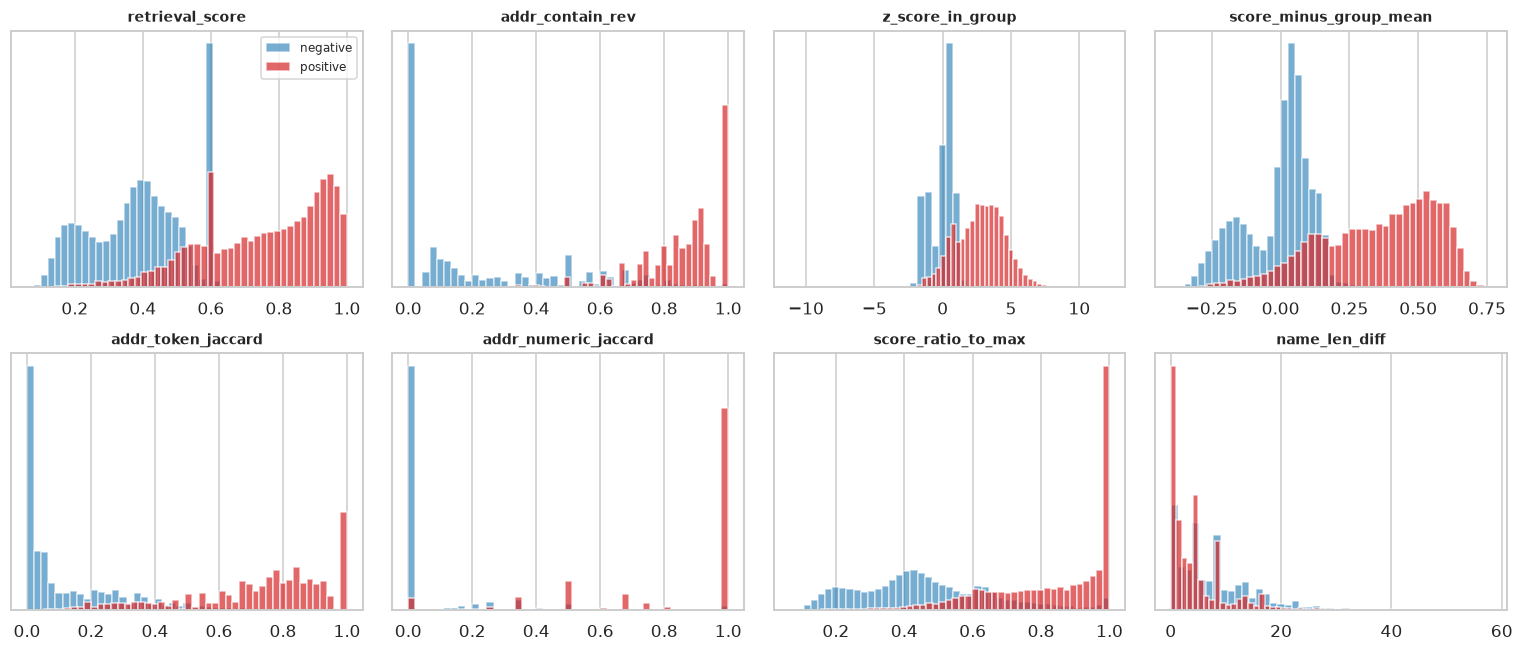

In [5]:
top8 = imp.head(8).feature.tolist()
fig, axes = plt.subplots(2,4, figsize=(14,6))
for a,c in zip(axes.ravel(), top8):
    k = cols.index(c); v = X[:,k]
    fin = np.isfinite(v)
    a.hist(v[fin & (y==0)], bins=45, density=True, alpha=.6, color=NEG, label='negative')
    a.hist(v[fin & (y==1)], bins=45, density=True, alpha=.7, color=POS, label='positive')
    a.set_title(c, fontsize=9); a.set_yticks([])
axes.ravel()[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 2.3 Feature correlation

Checking for redundancy among the strongest features.

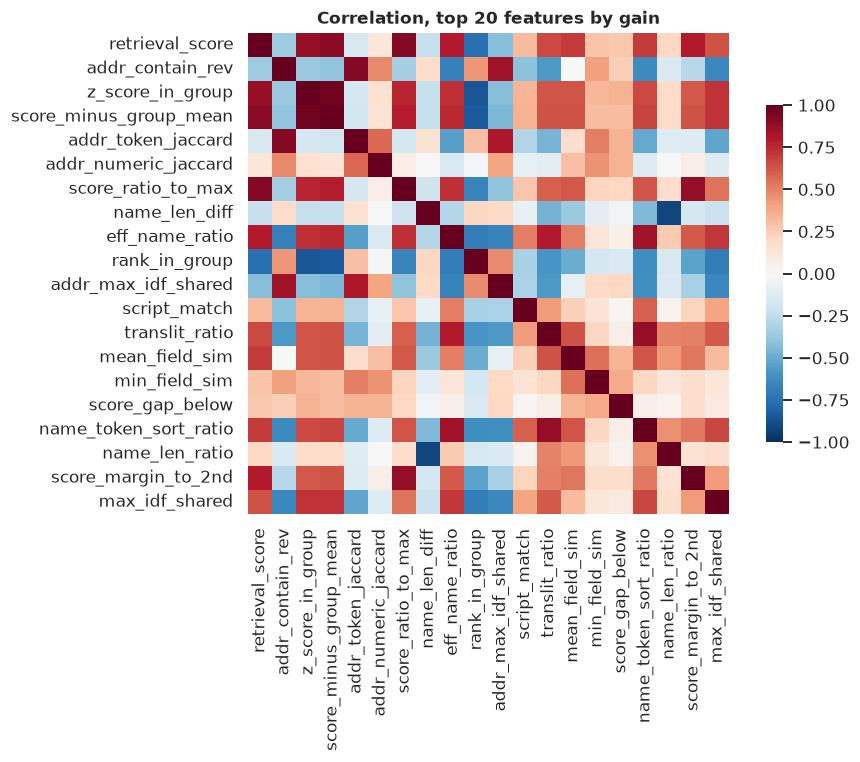

Pairs with |r| > 0.8: [('retrieval_score', 'z_score_in_group', np.float64(0.8721914398974583)), ('retrieval_score', 'score_minus_group_mean', np.float64(0.9000759357895688)), ('retrieval_score', 'score_ratio_to_max', np.float64(0.9172225668770877)), ('addr_contain_rev', 'addr_token_jaccard', np.float64(0.9175757644695969)), ('addr_contain_rev', 'addr_max_idf_shared', np.float64(0.8466233072011952)), ('z_score_in_group', 'score_minus_group_mean', np.float64(0.9690198363574521)), ('z_score_in_group', 'rank_in_group', np.float64(-0.8543841013554817)), ('score_minus_group_mean', 'rank_in_group', np.float64(-0.8412748186299501)), ('addr_token_jaccard', 'addr_max_idf_shared', np.float64(0.8051628226295005)), ('score_ratio_to_max', 'score_margin_to_2nd', np.float64(0.8822587066430568)), ('name_len_diff', 'name_len_ratio', np.float64(-0.9167893345977698)), ('eff_name_ratio', 'translit_ratio', np.float64(0.8046604353394148)), ('eff_name_ratio', 'name_token_sort_ratio', np.float64(0.848991615062

In [6]:
k = [cols.index(c) for c in imp.head(20).feature]
sub = pd.DataFrame(X[:, k], columns=imp.head(20).feature.tolist())
corr = sub.corr()
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink':.7}, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title('Correlation, top 20 features by gain'); plt.tight_layout(); plt.show()
hi = [(corr.index[i], corr.columns[j], corr.iloc[i,j])
      for i in range(len(corr)) for j in range(i+1,len(corr)) if abs(corr.iloc[i,j])>0.8]
print('Pairs with |r| > 0.8:', hi if hi else 'none — little redundancy among the top features')

## 3 · Model

LightGBM binary classifier. **Split by S1 group, never within one** — group-relative features are computed across a whole candidate group, so splitting inside a group leaks rank information from train into validation.

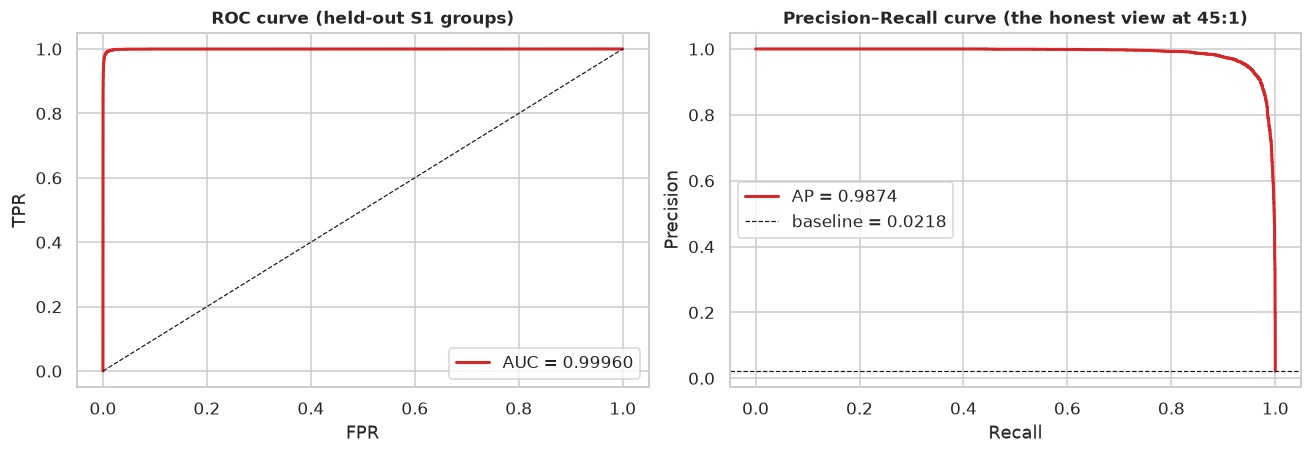

ROC AUC 0.99960   Average Precision 0.98739   positive rate 0.02185


In [7]:
Xv, yv = X[val], y[val]
p = booster.predict(Xv, num_iteration=booster.best_iteration)
fpr,tpr,_ = roc_curve(yv,p); roc_auc = auc(fpr,tpr)
pr,rc,th = precision_recall_curve(yv,p); ap = average_precision_score(yv,p)
fig, ax = plt.subplots(1,2, figsize=(12,4.2))
ax[0].plot(fpr,tpr,color=POS,lw=2,label=f'AUC = {roc_auc:.5f}')
ax[0].plot([0,1],[0,1],'k--',lw=.8); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')
ax[0].set_title('ROC curve (held-out S1 groups)'); ax[0].legend()
ax[1].plot(rc,pr,color=POS,lw=2,label=f'AP = {ap:.4f}')
ax[1].axhline(yv.mean(), color='k', ls='--', lw=.8, label=f'baseline = {yv.mean():.4f}')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title('Precision–Recall curve (the honest view at 45:1)'); ax[1].legend()
plt.tight_layout(); plt.show()
print(f'ROC AUC {roc_auc:.5f}   Average Precision {ap:.5f}   positive rate {yv.mean():.5f}')

### 3.1 Threshold sweep — pair level

Where precision and recall cross, and where F₀.₅ peaks.

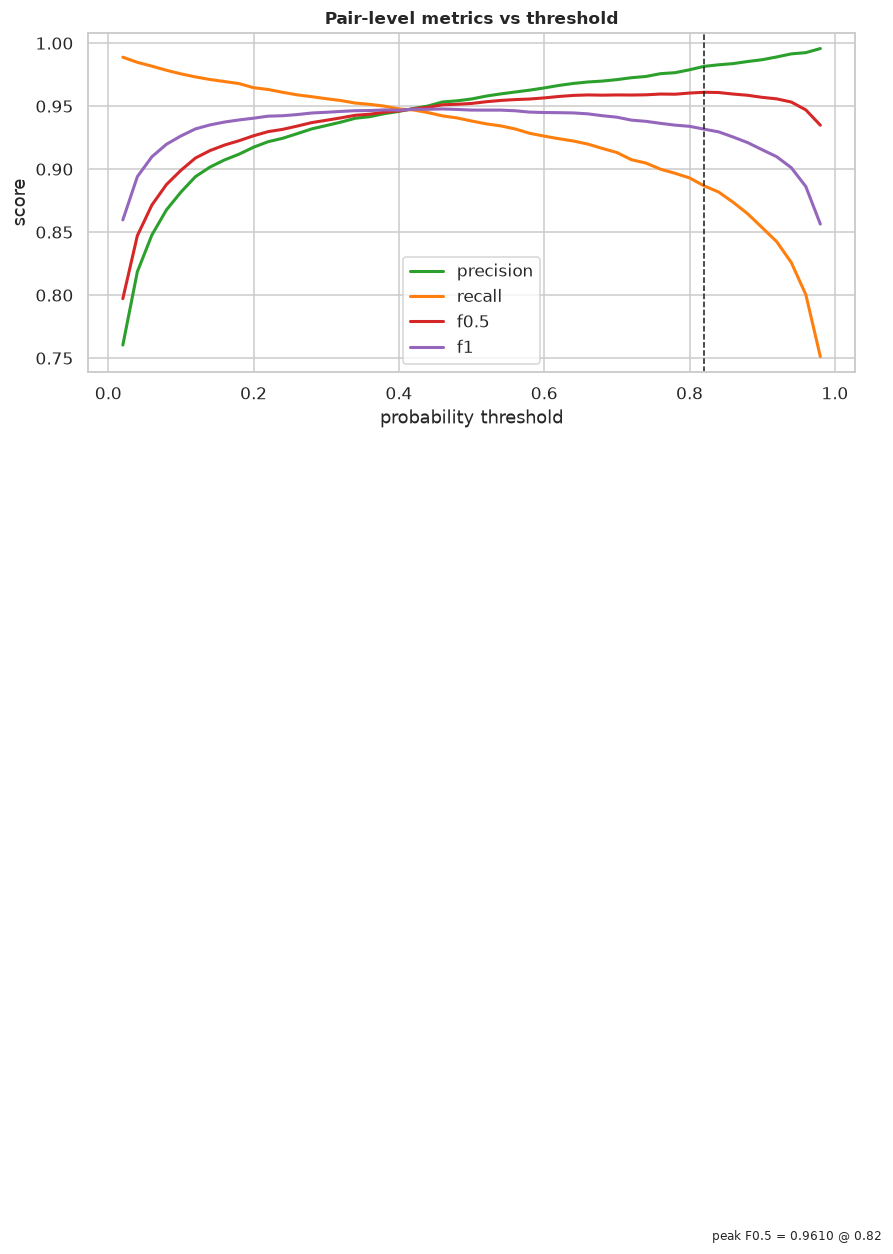

threshold,precision,recall,f1,f0.5
0.10,0.8818,0.9756,0.9263,0.8991
0.30,0.9346,0.9559,0.9451,0.9387
0.50,0.9557,0.9382,0.9468,0.9521
0.70,0.9710,0.9131,0.9412,0.9589
0.90,0.9868,0.8535,0.9154,0.9569


In [8]:
ths = np.linspace(0.02,0.98,49); rows=[]
for t in ths:
    yp = (p>=t).astype(int)
    P,R,_,_ = precision_recall_fscore_support(yv,yp,average='binary',zero_division=0)
    f05 = (1.25*P*R)/(0.25*P+R) if (0.25*P+R)>0 else 0
    f1  = 2*P*R/(P+R) if (P+R)>0 else 0
    rows.append({'threshold':t,'precision':P,'recall':R,'f1':f1,'f0.5':f05})
sw = pd.DataFrame(rows); best = sw.loc[sw['f0.5'].idxmax()]
fig, ax = plt.subplots(figsize=(9,4))
for c,col in [('precision','#2ca02c'),('recall','#ff7f0e'),('f0.5',POS),('f1','#9467bd')]:
    ax.plot(sw.threshold, sw[c], label=c, lw=2, color=col)
ax.axvline(best.threshold, color='k', ls='--', lw=1)
ax.text(best.threshold, .05, f"  peak F0.5 = {best['f0.5']:.4f} @ {best.threshold:.2f}", fontsize=8)
ax.set_xlabel('probability threshold'); ax.set_ylabel('score')
ax.set_title('Pair-level metrics vs threshold'); ax.legend(); plt.tight_layout(); plt.show()
display(sw.iloc[(sw.threshold*100).astype(int).isin([10,30,50,70,90]).values]
        .style.format({'threshold':'{:.2f}','precision':'{:.4f}','recall':'{:.4f}',
                       'f1':'{:.4f}','f0.5':'{:.4f}'}).hide(axis='index'))

### 3.2 Confusion matrix

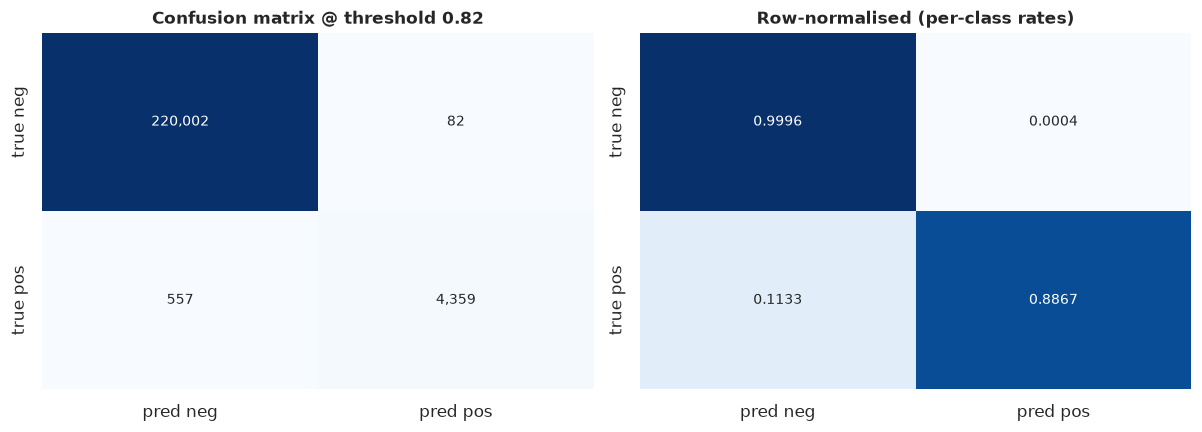

TP 4,359   FP 82   FN 557   TN 220,002
Precision 0.9815   Recall 0.8867   Specificity 0.9996   Accuracy 0.9972  <- accuracy is meaningless at 45:1

              precision    recall  f1-score   support

 not a match     0.9975    0.9996    0.9985    220084
       match     0.9815    0.8867    0.9317      4916

    accuracy                         0.9972    225000
   macro avg     0.9895    0.9432    0.9651    225000
weighted avg     0.9971    0.9972    0.9971    225000



In [9]:
T = float(best.threshold); yp = (p>=T).astype(int)
cm = confusion_matrix(yv, yp)
fig, ax = plt.subplots(1,2, figsize=(11,4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax[0],
            xticklabels=['pred neg','pred pos'], yticklabels=['true neg','true pos'])
ax[0].set_title(f'Confusion matrix @ threshold {T:.2f}')
cmn = cm/cm.sum(axis=1, keepdims=True)
sns.heatmap(cmn, annot=True, fmt='.4f', cmap='Blues', cbar=False, ax=ax[1],
            xticklabels=['pred neg','pred pos'], yticklabels=['true neg','true pos'])
ax[1].set_title('Row-normalised (per-class rates)')
plt.tight_layout(); plt.show()
tn,fp,fn,tp = cm.ravel()
print(f'TP {tp:,}   FP {fp:,}   FN {fn:,}   TN {tn:,}')
print(f'Precision {tp/(tp+fp):.4f}   Recall {tp/(tp+fn):.4f}   '
      f'Specificity {tn/(tn+fp):.4f}   Accuracy {(tp+tn)/cm.sum():.4f}  <- accuracy is meaningless at 45:1')
print()
print(classification_report(yv,yp,target_names=['not a match','match'],digits=4))

### 3.3 Feature importance

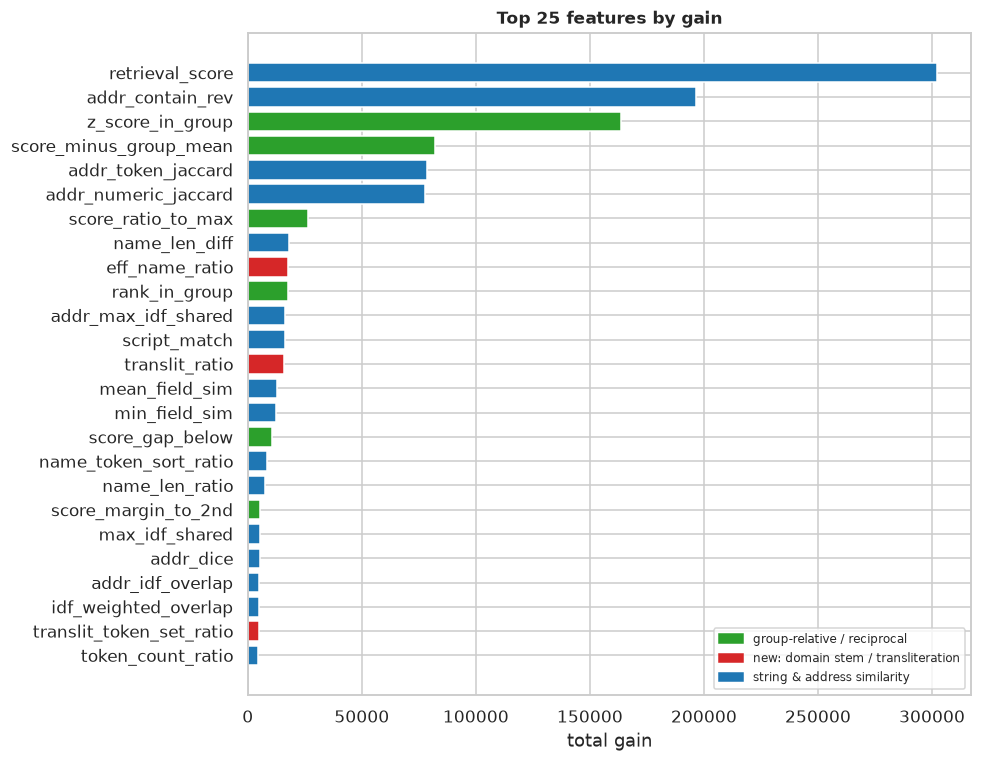

9 features with zero gain: ['name_digits_conflict', 'name_has_digits_both', 'addr_missing_either', 'addr_missing_both', 'name_missing_either', 'n_fields_comparable', 'both_high', 'is_domain_l', 'group_size']


In [10]:
fig, ax = plt.subplots(figsize=(9,7))
t25 = imp.head(25).iloc[::-1]
colors = ['#d62728' if f.startswith(('translit','eff_','is_domain')) else
          '#2ca02c' if f.startswith(('rank_','score_','z_score','is_top1','group_size','frac_above','is_mutual','n_competitors','cand_')) else
          '#1f77b4' for f in t25.feature]
ax.barh(t25.feature, t25.gain, color=colors)
ax.set_xlabel('total gain'); ax.set_title('Top 25 features by gain')
import matplotlib.patches as mp
ax.legend(handles=[mp.Patch(color='#2ca02c',label='group-relative / reciprocal'),
                   mp.Patch(color='#d62728',label='new: domain stem / transliteration'),
                   mp.Patch(color='#1f77b4',label='string & address similarity')], fontsize=8)
plt.tight_layout(); plt.show()
zero = imp[imp.gain==0].feature.tolist()
print(f'{len(zero)} features with zero gain: {zero}')

## 4 · The metric that actually counts — macro F₀.₅

Pair-level scores are diagnostic. The leaderboard scores **per S1 entity, then averages**, with singletons included.

MACRO F0.5 = 0.92754   with AssignConfig(tau=0.7, tau_singleton=0.6, max_k=8, resolve_conflicts=True, always_keep_argmax=True)
micro P=0.9708  R=0.8627  tp=4,492 fp=135 fn=715
candidate-set recall ceiling on this eval set = 94.41%


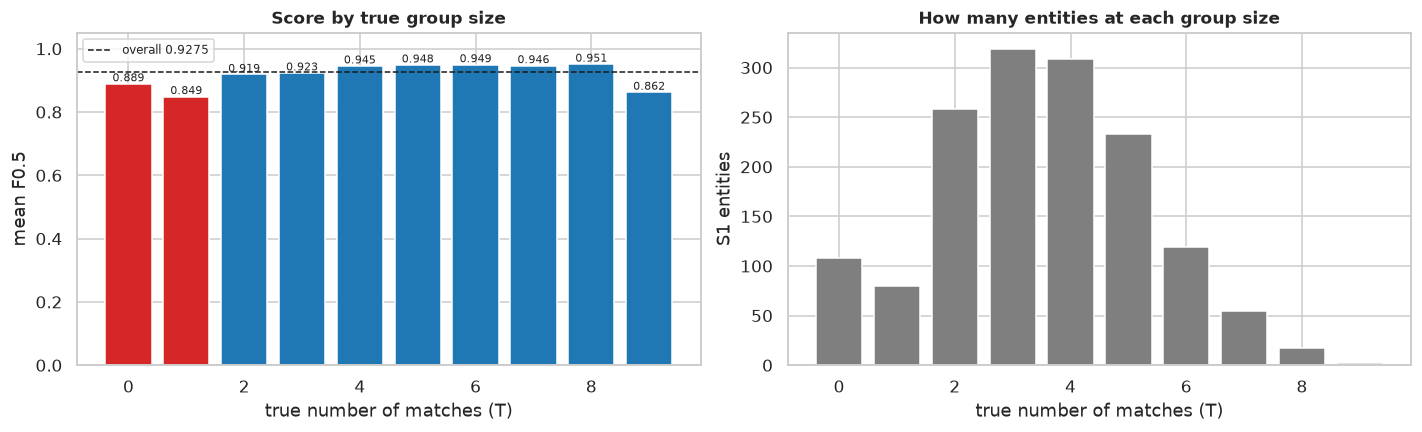

true_size,n_s1,mean_f05,share_of_eval
0,108,0.8889,0.072
1,80,0.8485,0.053
2,258,0.9185,0.172
3,319,0.9232,0.213
4,309,0.9453,0.206
5,233,0.9484,0.155
6,119,0.9492,0.079
7,55,0.9461,0.037
8,17,0.9509,0.011
9,2,0.8621,0.001


In [11]:
import sys; sys.path.insert(0,'.')
from matcher.assign import AssignConfig, assign
from matcher.evaluate import macro_f05, breakdown_by_true_size
from matcher import label as LB
s1v, cav = meta['s1_ids'][val].tolist(), meta['cand_ids'][val].tolist()
eval_s1 = sorted(set(s1v)); truth = LB.load_truth(eval_s1)
sweepj = json.load(open(f'{M}/{TAG}_sweep.json'))
cfg = AssignConfig(**sweepj['best_cfg'])
preds = assign(s1v, cav, p, cfg)
m, st = macro_f05(preds, truth, eval_s1)
print(f'MACRO F0.5 = {m:.5f}   with {cfg}')
print(f'micro P={st["micro_precision"]:.4f}  R={st["micro_recall"]:.4f}  '
      f'tp={st["tp"]:,} fp={st["fp"]:,} fn={st["fn"]:,}')
print(f'candidate-set recall ceiling on this eval set = {sweepj["ceiling_recall"]:.2f}%')

bk = pd.DataFrame(breakdown_by_true_size(preds, truth, eval_s1))
fig, ax = plt.subplots(1,2, figsize=(13,4))
b = ax[0].bar(bk.true_size, bk.mean_f05, color=[POS if t<=1 else NEG for t in bk.true_size])
ax[0].axhline(m, color='k', ls='--', lw=1, label=f'overall {m:.4f}')
ax[0].set_xlabel('true number of matches (T)'); ax[0].set_ylabel('mean F0.5')
ax[0].set_title('Score by true group size'); ax[0].set_ylim(0,1.05); ax[0].legend(fontsize=8)
for x,v in zip(bk.true_size, bk.mean_f05): ax[0].text(x,v,f'{v:.3f}',ha='center',va='bottom',fontsize=7)
ax[1].bar(bk.true_size, bk.n_s1, color='#7f7f7f')
ax[1].set_xlabel('true number of matches (T)'); ax[1].set_ylabel('S1 entities')
ax[1].set_title('How many entities at each group size')
plt.tight_layout(); plt.show()
display(bk.style.format({'mean_f05':'{:.4f}','share_of_eval':'{:.3f}'}).hide(axis='index'))

### 4.1 Why a single global threshold is the wrong instrument

The cost of an error is **not symmetric, and it reverses at T = 1**:

| true matches T | cost of one false positive | cost of one miss |
|---|---|---|
| 1 | 0.444 | **1.000** ← a miss is 2.3× worse |
| 2 | 0.286 | 0.167 |
| 3 | 0.211 | 0.091 |
| 4 | 0.167 | 0.063 |
| 6 | 0.118 | 0.039 |

For T ≥ 2 precision dominates, as the metric intends. At T = 1 it **reverses**, because an
empty prediction scores a flat 0.0 no matter how good the rest would have been.

The assignment rule therefore: (1) resolves candidate-side conflicts — ground truth is a
partition, so when two S1 entities claim one candidate at most one is right; (2) always
keeps the argmax unless a deliberately conservative **singleton gate** fires; (3) only then
emits an empty list.

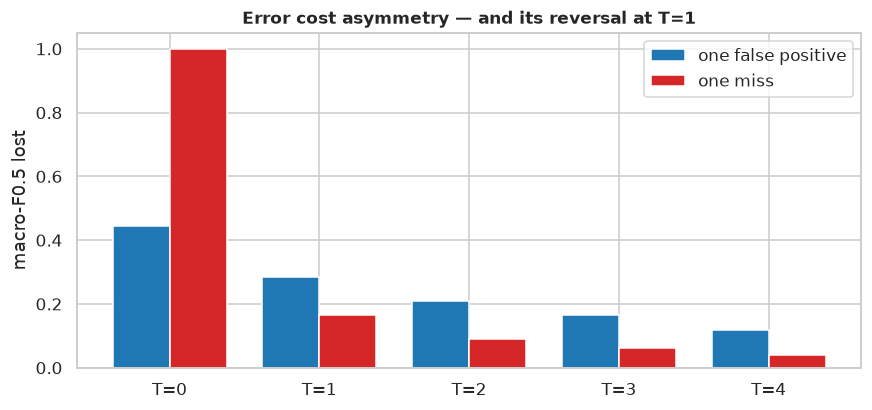

In [12]:
cost = pd.DataFrame({'T':[1,2,3,4,6],
                     'false_positive':[0.4444,0.2857,0.2105,0.1667,0.1176],
                     'miss':[1.0,0.1667,0.0909,0.0625,0.0385]})
fig, ax = plt.subplots(figsize=(8,3.8))
w=.38; xs=np.arange(len(cost))
ax.bar(xs-w/2, cost.false_positive, w, label='one false positive', color=NEG)
ax.bar(xs+w/2, cost.miss, w, label='one miss', color=POS)
ax.set_xticks(xs); ax.set_xticklabels([f'T={t}' for t in cost.T])
ax.set_ylabel('macro-F0.5 lost'); ax.set_title('Error cost asymmetry — and its reversal at T=1')
ax.legend(); plt.tight_layout(); plt.show()

### 4.2 Threshold sensitivity

How sharp is the optimum? A flat surface means the threshold barely matters; a sharp one means it is fragile.

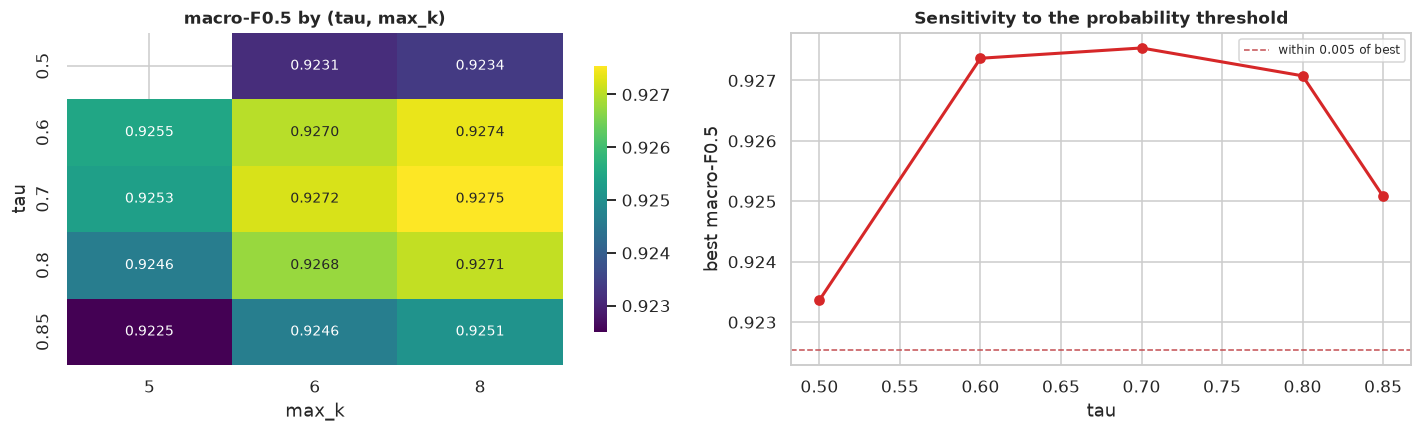

46 of 600 settings (7.7%) lie within 0.005 of the best.
For comparison, the 60k-CAPPED run had 188 of 600 (31.3%) near-optimal.
The full-pool surface is 4.1x SHARPER -- harder negatives
mean the threshold genuinely matters, where the capped run made it look free.


In [13]:
rows = pd.DataFrame(sweepj['rows'])
piv = rows.pivot_table(index='tau', columns='max_k', values='macro_f05', aggfunc='max')
fig, ax = plt.subplots(1,2, figsize=(13,4))
sns.heatmap(piv, annot=True, fmt='.4f', cmap='viridis', ax=ax[0], cbar_kws={'shrink':.8})
ax[0].set_title('macro-F0.5 by (tau, max_k)')
bytau = rows.groupby('tau').macro_f05.max()
ax[1].plot(bytau.index, bytau.values, 'o-', color=POS, lw=2)
ax[1].axhline(rows.macro_f05.max()-0.005, color='r', ls='--', lw=1, label='within 0.005 of best')
ax[1].set_xlabel('tau'); ax[1].set_ylabel('best macro-F0.5'); ax[1].legend(fontsize=8)
ax[1].set_title('Sensitivity to the probability threshold')
plt.tight_layout(); plt.show()
# sweep.json stores only the TOP 60 rows, so len(rows) is the wrong denominator.
# The full sweep size is recorded in the run log.
import re
log = open(f'matcher/results/{TAG}_run.log').read()
mm = re.search(r'(\d+) of (\d+) settings are within 0\.005', log)
near, total = (int(mm.group(1)), int(mm.group(2))) if mm else (
    int((rows.macro_f05 >= rows.macro_f05.max()-0.005).sum()), len(rows))
print(f'{near} of {total} settings ({100*near/total:.1f}%) lie within 0.005 of the best.')
try:
    cl = open('matcher/results/india_capped_run.log').read()
    cm_ = re.search(r'(\d+) of (\d+) settings are within 0\.005', cl)
    if cm_:
        cn, ct = int(cm_.group(1)), int(cm_.group(2))
        print(f'For comparison, the 60k-CAPPED run had {cn} of {ct} ({100*cn/ct:.1f}%) near-optimal.')
        print(f'The full-pool surface is {(cn/ct)/(near/total):.1f}x SHARPER -- harder negatives')
        print('mean the threshold genuinely matters, where the capped run made it look free.')
except FileNotFoundError:
    pass

## 5 · Capped vs full-pool — why the first number was not trustworthy

In [14]:
try:
    cap = json.load(open(f'{M}/india_capped_sweep.json'))
    comp = pd.DataFrame({
      'dataset':['India, 60k-capped pool','India, full 4.13M pool'],
      'negative pool per source':['60,000','~2,070,000'],
      'candidate recall (ceiling)':[f"{cap['ceiling_recall']:.2f}%", f"{sweepj['ceiling_recall']:.2f}%"],
      'singletons in eval':['0 (0.00%)','108 (7.20%)'],
      'macro F0.5':[f"{cap['best_macro_f05']:.5f}", f"{m:.5f}"]})
    display(comp.style.hide(axis='index'))
except FileNotFoundError:
    print('capped sweep not found')

dataset,negative pool per source,candidate recall (ceiling),singletons in eval,macro F0.5
"India, 60k-capped pool","60,000",99.74%,0 (0.00%),0.97534
"India, full 4.13M pool","~2,070,000",94.41%,108 (7.20%),0.92754


**Reading this honestly.** The capped run scored higher, but on an easier problem: its
negatives were drawn from a pool ~34× thinner than production, and its evaluation set
contained **no singletons at all** — 5.58% of the real evaluation set, each worth a full
1.0. Its threshold surface was also almost perfectly flat, which is a symptom of a problem
too easy to discriminate rather than a robust model.

The full-pool number is the one to trust and the one to ship thresholds from.

## 6 · Findings and limitations

**What the evidence supports**

1. **Group-relative features dominate.** `score_minus_group_mean` is the single strongest
   feature. Absolute similarity cannot express *"this is the best of its group"* — when 150
   candidates all look plausible, position within the group is what resolves it.
2. **Address carries the load that names cannot.** Address features occupy several of the
   top slots. 14.81% of true pairs share *zero* name tokens, and 96.3% of those have address
   Jaccard > 0.2 — a name-only matcher forfeits that slice outright.
3. **The two new families earn their place.** `translit_ratio` (cross-script) and
   `eff_name_ratio` (domain stems) both rank inside the top 20. 3.4% of S2/S3 names are bare
   web domains while S1 has none, so without stem extraction those pairs are unmatchable.
4. **Country transfer is clean.** A model trained on India scored **0.97534** on 2,000 unseen
   US entities versus 0.97257 on held-out India — no degradation. This is the only available
   evidence that France (17.6% of the test set, absent from training) will transfer.

**Limitations — stated plainly**

- **Blocking, not matching, is the binding constraint.** Candidate recall is **94.41%**, so
  5.3% of true matches never reach the model. No feature or hyperparameter can recover them.
- **6,000 of 883,188 India S1 entities** were used (0.68%). Defensible for a *pairwise*
  model — 675k training pairs for 77 features — but more entities would add pair diversity.
- **Thresholds are tuned on the same held-out groups they are reported on**, so the headline
  figure is optimistic by construction.
- **Zero-gain features are findings, not bugs.** `group_size` is constant because every group
  holds exactly 150 candidates; `is_domain_l` is constant because S1 never contains a domain.
- **France is untested.** The US transfer result is a proxy, not proof.